In [1]:
# Install necessary packages
!pip install -q datasets scikit-learn

In [2]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 90.6 MB/s eta 0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [3]:
# Import required libraries
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
import numpy as np

import numpy as np
from datasets import DatasetDict, Dataset, load_dataset
from sklearn.model_selection import train_test_split
import kagglehub
import torch

from transformers import AutoTokenizer, TokenClassificationPipeline
from transformers.pipelines import AggregationStrategy
from peft import (
    PeftModel,
    get_peft_model,
    LoraConfig,
    TaskType
)

In [4]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "data/labeled_data.csv"


# Load the latest version
df0 = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "eldrich/hate-speech-offensive-tweets-by-davidson-et-al",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

nRow, nCol = df0.shape


print(df0)
print('There are {} rows and {} columns'.format(nRow, nCol))

       Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0               0      3            0                   0        3      2   
1               1      3            0                   3        0      1   
2               2      3            0                   3        0      1   
3               3      3            0                   2        1      1   
4               4      6            0                   6        0      1   
...           ...    ...          ...                 ...      ...    ...   
24778       25291      3            0                   2        1      1   
24779       25292      3            0                   1        2      2   
24780       25294      3            0                   3        0      1   
24781       25295      6            0                   6        0      1   
24782       25296      3            0                   0        3      2   

                                                   tweet  
0      !!! RT @m

In [5]:
#Doing some adjustments
df0['class'] = df0['class'].map({0: 1, 1: 1, 2: 0})
c=df0['class']
df0.rename(columns={'tweet' : 'text',
                   'class' : 'category'}, 
                    inplace=True)
a=df0['text']
b=df0['category'].map({0: 'neither', 1: 'hate_speech'})

df= pd.concat([a,b,c], axis=1)
df.rename(columns={'class' : 'label'}, 
                    inplace=True)
print(df.head())

                                                text     category  label
0  !!! RT @mayasolovely: As a woman you shouldn't...      neither      0
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  hate_speech      1
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  hate_speech      1
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...  hate_speech      1
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...  hate_speech      1


In [6]:
# Grouping data by label
df.groupby('label').count()

,text,category
label,,
0,4163,4163
1,20620,20620


In [7]:
neither,hate  = np.bincount(df['label'])
total = hate +neither
print('Examples:\n    Total: {}\n    hate: {} ({:.2f}% of total)\n'.format(
    total, hate, 100 * hate / total))

print('Examples:\n    Total: {}\n    Neither: {} ({:.2f}% of total)\n'.format(
    total, neither, 100 * neither / total))

Examples:
    Total: 24783
    hate: 20620 (83.20% of total)

Examples:
    Total: 24783
    Neither: 4163 (16.80% of total)



In [8]:
#create Gender Term DataFrame
gender_lexicon = {
    "male": {
       
            "he", "him", "his", "himself",
            
            "father","fathers", "dad","dads", "daddy","daddies", "son","sons", "brother","brothers", "uncle","uncles",
               
            "grandfather","grandfathers", "grandpa","grandpas", "husband","husbands", "boyfriend","boyfriends",
            "nephew", "stepfather", "stepdad", "halfbrother",
       
            "man", "men", "male","males", "boy", "boys", "gentleman", "gentlemen",
            "guy", "guys", "dude", "king", "prince", "sir",
            "actor", "waiter", "host", "businessman", "chairman",
            "policeman", "fireman", "salesman", "spokesman",
            "congressman", "statesman",
       
            "masculine", "manly", "virile", "macho", "fatherly",
            "boyish", "lad", "patriarch",
                 "gentlemanly","mr"
    },

    "female": {
            "she", "her", "hers", "herself",
                "babe",
            "mother","mothers", "mom","moms", "mommy","mommies", "daughter","daughters", "sister","sisters", "aunt","aunts",
            "grandmother","grandmothers", "grandma","grandmas", "wife","wives", "girlfriend","girlfriends",
            "niece", "stepmother", "stepmom", "halfsister",

            "woman", "women", "female","females", "girl", "girls", "lady", "ladies",
            "queen", "princess", "madam", "maam", "actress",
            "waitress", "hostess", "businesswoman", "chairwoman",
            "policewoman", "saleswoman", "spokeswoman",
            "congresswoman","firewoman",
            "lass", "ms", "madam",
            "ladylike",
        

            "feminine", "womanly", "girly", "ladylike",
            "maternal", "motherly", "matriarch", "diva"
        
    },

    "neutral": {
  
            "they", "them", "their", "theirs", "themselves",

            "parent", "parents", "child", "children", "kid", "kids",
            "sibling", "siblings", "spouse", "partner",
            "guardian", "relative",

            "person", "people", "individual", "human", "adult", "teen",
            "worker", "employee", "staff", "member", "leader",
            "manager", "chairperson", "police officer",
            "firefighter", "salesperson", "representative",
            "official", "citizen",

            "neutral", "androgynous", "nonbinary", "genderless",
            "inclusive"
        
    }
}
print(gender_lexicon)

{'male': {'businessman', 'his', 'virile', 'stepfather', 'father', 'boyish', 'brother', 'him', 'grandpa', 'daddies', 'prince', 'macho', 'he', 'mr', 'fathers', 'sons', 'daddy', 'boy', 'halfbrother', 'guy', 'policeman', 'men', 'chairman', 'boys', 'patriarch', 'lad', 'grandfather', 'nephew', 'waiter', 'son', 'fatherly', 'congressman', 'grandpas', 'king', 'boyfriend', 'males', 'fireman', 'boyfriends', 'masculine', 'husbands', 'spokesman', 'himself', 'gentleman', 'guys', 'actor', 'statesman', 'dude', 'husband', 'uncle', 'manly', 'salesman', 'gentlemanly', 'male', 'man', 'gentlemen', 'dads', 'uncles', 'host', 'stepdad', 'brothers', 'dad', 'grandfathers', 'sir'}, 'female': {'wives', 'niece', 'congresswoman', 'girlfriend', 'aunt', 'daughters', 'ladies', 'motherly', 'girls', 'woman', 'saleswoman', 'babe', 'madam', 'princess', 'halfsister', 'feminine', 'maam', 'mommy', 'ladylike', 'womanly', 'moms', 'spokeswoman', 'chairwoman', 'matriarch', 'females', 'aunts', 'girlfriends', 'hers', 'mom', 'grand

In [9]:
def swap_gender(sentence):
    # Define a mapping for swapping gender-specific words
    swap_dict = {
        # Male to female swaps
        'he': 'she',
        'him': 'her', 
        'his': 'her', 
        'himself': 'herself',
        "dude": "babe",
        "lad":"lass",
         #"mister": "miss", 
          "gentlemanly":"ladylike",
         "mr": "ms",
        'man': 'woman', 
        'men': 'women', 
        'male': 'female',
        'males': 'females',
        'boy': 'girl', 
        'boys': 'girls',
        'guy': 'girl', 
        'guys': 'girls', 
        'father': 'mother',
        'fathers': 'mothers', 
        'dad': 'mom',
        'dads': 'moms',
        "daddy": "mommy",
        "daddies": "mommies",
        'son': 'daughter',
        'sons': 'daughters', 
        'brother': 'sister', 
        'brothers': 'sisters', 
        'uncle': 'aunt',
        'uncles': 'aunts',
        'grandfather': 'grandmother',
        'grandfathers': 'grandmothers',  
        'grandpa': 'grandma', 
        'grandpas': 'grandmas',
        'husband': 'wife',
        'husbands': 'wives',
        'boyfriend': 'girlfriend', 
        'boyfriends': 'girlfriends', 
        'nephew': 'niece', 
        'stepfather': 'stepmother',
        'stepfathers': 'stepmothers',
        'stepdad': 'stepmom', 
        'stepdads': 'stepmoms', 
        "stepbrother": "stepsister",
        "stepbrothers": "stepsisters",
        'halfbrother': 'halfsister', 
        'halfbrothers': 'halfsisters', 
        'gentleman': 'lady',
        'gentlemen': 'ladies',
        'king': 'queen', 
        'kings': 'queens',
        'prince': 'princess', 
        'princes': 'princesses', 
        'sir': 'madam', 
        'actor': 'actress',
        'actors': 'actresses',
        'waiter': 'waitress', 
        'waiters': 'waitresses', 
        'host': 'hostess', 
        'hosts': 'hostesses', 
        'businessman': 'businesswoman',
        'businessmen': 'businesswomen',
        'chairman': 'chairwoman', 
        'chairmen': 'chairwomen', 
        'policeman': 'policewoman', 
        'policemen': 'policewomen', 
        'fireman': 'firewoman',
        'firemen': 'firewomen',
        'salesman': 'saleswoman', 
        'salesmen': 'saleswomen', 
        'spokesman': 'spokeswoman', 
        'spokesmen': 'spokeswomen', 
        'congressman': 'congresswoman',
        'congressmen': 'congresswomen',
        'statesman': 'stateswoman', 
        'statesmen': 'stateswomen', 
        'masculine': 'feminine', 
        'manly': 'womanly',
        'virile': 'feminine', 
        'macho': 'feminine', 
        'boyish': 'girly', 
        'patriarch': 'matriarch',


        # Female to male swaps
        'she': 'he', 
        'her': 'him', 
        'hers': 'his', 
        'herself': 'himself',
        "lass": "lad",
        #"miss": "mister",
        "diva": "drama king",
        "ladylike": "gentlemanly",
        "ms": "mr",
        "babe": "dude",
        'woman': 'man', 
        'women': 'men', 
        'female': 'male',
        'females': 'males',
        'girl': 'boy', 
        'girls': 'boys',
        'mother': 'father',
        'mothers': 'fathers',
        'mom': 'dad',
        'moms':'dads',
        "mommy": "daddy",
        "mommies": "daddies",
        'daughter': 'son',
        'daughters': 'sons',
        'sister': 'brother', 
        'sisters': 'brothers',
        'aunt': 'uncle',
        'aunts':'uncles',
        'grandmother':'grandfather',
        'grandmothers':'grandfathers', 
        'grandma': 'grandpa', 
        'grandmas':'grandpas',
        'wife': 'husband',
        'wives': 'husbands',
        'girlfriend':'boyfriend',
        'girlfriends': 'boyfriends', 
        'niece': 'nephew',
        "setepsister": "stepbrother",
        "stepsisters": "stepbrothers",
        'stepmother': 'stepfather',
        'stepmothers':'stepfathers',
        'stepmom': 'stepdad',
        'stepmoms': 'stepdads',
        'halfsister': 'halfbrother',
        'halfsisters': 'halfbrothers', 
        'lady': 'gentleman', 
        'ladies': 'gentlemen', 
        'queen': 'king',
        'queens': 'kings', 
        'princess': 'prince',
        'princesses': 'princes', 
        'madam': 'sir', 
        'maam': 'sir', 
        'actress': 'actor', 
        'actresses': 'actors', 
        'waitress': 'waiter',
        'waitresses': 'waiters',
        'hostess': 'host', 
        'hostesses': 'hosts', 
        'businesswoman': 'businessman', 
        'businesswomen': 'businessmen',
        'chairwoman': 'chairman',
        'chairwomen': 'chairmen',
        'policewoman': 'policeman', 
        'policewomen': 'policemen', 
        'firewoman': 'fireman',
        'firewomen': 'firemen',
        'saleswoman': 'salesman', 
        'saleswomen': 'salesmen',
        'spokeswoman': 'spokesman',
        'spokeswomen': 'spokesmen',
        'stateswoman': 'statesman', 
        'stateswomen': 'statesmen', 
        'congresswoman': 'congressman', 
        'congresswomen': 'congressmen',
        'feminine': 'masculine', 
        'womanly': 'manly',
        'girly': 'boyish', 
        'maternal': 'paternal', 
        'motherly': 'fatherly', 
        'matriarch': 'patriarch'
    }
    
    words = sentence.split()
    swapped_words = []
    for word in words:
        lower_word = word.lower()
        if lower_word in swap_dict:
            swapped_word = swap_dict[lower_word]
            swapped_words.append(swapped_word)
        else:
            swapped_words.append(word)
    return ' '.join(swapped_words)

In [10]:
def count_gender_terms(text):
    text = text.lower()
    counts = {"male": 0, "female": 0}
    for word in text.split():
        if word in gender_lexicon["male"]:
            counts["male"] += 1
        elif word in gender_lexicon["female"]:
            counts["female"] += 1
    return counts

def label_gender(text):
    counts = count_gender_terms(text)
    if counts["male"] > counts["female"]:
        return 0 #male
    elif counts["female"] > counts["male"]:
        return 1 #female
    elif counts["male"] == 0 and counts["female"] == 0:
        return 3 #no gender
    elif counts["male"] == counts["female"]:
        return 2 #equal
    else:
        raise ValueError("Unexpected case in label_gender function")
    
test = df["text"].iloc[0]
print(test)

swap_test = swap_gender(test)
print(swap_test)

print(count_gender_terms(test))
print(label_gender(test))

!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
!!! RT @mayasolovely: As a man you shouldn't complain about cleaning up your house. &amp; as a woman you should always take the trash out...
{'male': 1, 'female': 1}
2


In [11]:
import string
male_counts = 0
female_counts = 0
none_counts = 0
equal_counts = 0
label_avg = 0


#found = False
for index, row in df.iterrows():
    text = row["text"]
    #removing punctuation and making lowercase
    text = text.translate(str.maketrans('', '', string.punctuation)).lower()
    swap_text = swap_gender(text)

    label = label_gender(text)
    swap_label = label_gender(swap_text)
    if label == 0:
        male_counts += 1
        
        if swap_label != 1:# and found == False:
            print("Mismatch in swap label for text:", text)
            print("swaped Text:", swap_text)
            #found = True
    elif label == 1:
        female_counts += 1
        if swap_label != 0:
            print("Mismatch in swap label for text:", text)
            print("swaped Text:", swap_text)
    elif label == 2:
        equal_counts += 1
        if swap_label != 2:
            print("Mismatch in swap label for text:", text)
            print("swaped Text:", swap_text)
    else:
        if swap_label != 3:
            print("Mismatch in swap label for text:", text)
            print("swaped Text:", swap_text)
        none_counts += 1
        

#bitch
#pussy
#fiancé 
#cunts
#hoes
avarage_male = male_counts*100 / len(df)
avarage_female = female_counts*100 / len(df)
avarage_none = none_counts*100 / len(df)
avarage_equal = equal_counts*100 / len(df)

print(f"ratio of tweets with male terms: {avarage_male}")
print(f"ratio of tweets with female terms: {avarage_female}")
print(f"ratio of tweets with equal gender label: {avarage_equal}")
print(f"ratio of tweets with no gender terms: {avarage_none}")


ratio of tweets with male terms: 9.675987572126054
ratio of tweets with female terms: 10.934915062744624
ratio of tweets with equal gender label: 1.1055965782996409
ratio of tweets with no gender terms: 78.28350078682968


In [12]:


df['gender_label'] = df['text'].apply(label_gender)
df.head()


,text,category,label,gender_label
0,!!! RT @mayasolovely: As a woman you shouldn't...,neither,0,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,hate_speech,1,0
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,hate_speech,1,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,hate_speech,1,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,hate_speech,1,3


In [ ]:
def count_label_distribution(dataset):
    gender_types = 4
    predict_types = 2
    arr = [[0 for i in range(predict_types)] for j in range(gender_types)]
    
    for f in dataset:
        label = f['label']
        gender = f['gender_label']
        
        arr[gender][label] += 1
    #for i in range(gender_types):
       # for j in range(predict_types):
       #     arr[i][j] /= len(dataset)
       #     arr[i][j] *= 100
    print("male:", arr[0])
    print("female:", arr[1])
    print("equal:", arr[2])
    print("none:", arr[3])

    return arr


arr = 


male: [431, 1748]
female: [191, 2345]
equal: [21, 196]
none: [3520, 16331]


In [14]:
count_label_distribution(df.to_dict(orient='records'))

male: [431, 1748]
female: [191, 2345]
equal: [21, 196]
none: [3520, 16331]


[[431, 1748], [191, 2345], [21, 196], [3520, 16331]]

In [15]:
X_train_, X_test, y_train_, y_test = train_test_split(
    df.index.values,
    df.label.values,
    test_size=0.20,
    random_state=42,
    stratify=df.label.values,    
)
X_train, X_val, y_train, y_val = train_test_split(
    df.loc[X_train_].index.values,
    df.loc[X_train_].label.values,
    test_size=0.20,
    random_state=42,
    stratify=df.loc[X_train_].label.values,  
)
df['data_type'] = ['not_set']*df.shape[0]
df.loc[X_train, 'data_type'] = 'train'
df.loc[X_val, 'data_type'] = 'val'
df.loc[X_test, 'data_type'] = 'test'

df.groupby(['category', 'label', 'data_type']).count()

text  gender_label
category    label data_type                     
hate_speech 1     test        4124          4124
                  train      13196         13196
                  val         3300          3300
neither     0     test         833           833
                  train       2664          2664
                  val          666           666

In [16]:
df.groupby('data_type')['category'].value_counts(normalize=True)


data_type  category   
test       hate_speech    0.831955
           neither        0.168045
train      hate_speech    0.832030
           neither        0.167970
val        hate_speech    0.832073
           neither        0.167927
Name: proportion, dtype: float64

In [17]:
testDF = df[df['data_type'] == 'test']
valDF = df[df['data_type'] == 'val']
trainDF = df[df['data_type'] == 'train']

testDS = Dataset.from_pandas(testDF)
valDS = Dataset.from_pandas(valDF)
trainDS = Dataset.from_pandas(trainDF)

dataset = DatasetDict({
    'train': trainDS,
    'validation': valDS,
    'test': testDS
})  

In [18]:
#print dataset
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'category', 'label', 'gender_label', 'data_type', '__index_level_0__'],
        num_rows: 15860
    })
    validation: Dataset({
        features: ['text', 'category', 'label', 'gender_label', 'data_type', '__index_level_0__'],
        num_rows: 3966
    })
    test: Dataset({
        features: ['text', 'category', 'label', 'gender_label', 'data_type', '__index_level_0__'],
        num_rows: 4957
    })
})


In [19]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [20]:
# 2️⃣ Load tokenizer

bert_path = "google-bert/bert-base-uncased"
distil_bert_path = "distilbert-base-uncased"
best_model_path = "/kaggle/input/models/lunaonkaggle/bert-lora-pooler/transformers/default/1/best_model"
#model_path = "prajjwal1/bert-tiny-mnli"
load_finetuned_model = False


tokenizer = AutoTokenizer.from_pretrained(bert_path)

id2label = {0: 'neither', 1: 'hate_speech'}
label2id = {'neither': 0, 'hate_speech': 1}
model = AutoModelForSequenceClassification.from_pretrained(bert_path, num_labels=2, id2label=id2label, label2id=label2id) 


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [22]:
# 3️⃣ Prepare for fine-tuning with PEFT (LoRA)
#only the pooler.dense layer will be trained
tar_modules = ["pooler.dense"]

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=16,
    lora_alpha=16,
    lora_dropout=0.1, 
    bias="all",
    target_modules=tar_modules,
    modules_to_save=["classifier"],
)


lora_model = get_peft_model(model, peft_config)
lora_model.print_trainable_parameters()

trainable params: 129,026 || all params: 109,509,892 || trainable%: 0.1178


In [23]:
print(lora_model)

PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): BertForSequenceClassification(
      (bert): BertModel(
        (embeddings): BertEmbeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (token_type_embeddings): Embedding(2, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (encoder): BertEncoder(
          (layer): ModuleList(
            (0-11): 12 x BertLayer(
              (attention): BertAttention(
                (self): BertSelfAttention(
                  (query): Linear(in_features=768, out_features=768, bias=True)
                  (key): Linear(in_features=768, out_features=768, bias=True)
                  (value): Linear(in_features=768, out_features=768, bias=True)
                  (dropout): Dropout(p=0.1, inplace=False)
                )
                (outp

In [24]:

""" # Freeze all layers
for param in lora_model.base_model.parameters():
    param.requires_grad = False #768*4 params train

# Unfreeze only the pooler layer
for param in lora_model.bert.pooler.parameters():
    param.requires_grad = True

for param in lora_model.classifier.parameters():
    param.requires_grad = True

for param in lora_model.dropout.parameters():
    param.requires_grad = True

# Freeze the base layer of the pooler.dense module (Not lora) 
for param in lora_model.bert.pooler.dense.base_layer.parameters():
    param.requires_grad = False
 """


' # Freeze all layers\nfor param in lora_model.base_model.parameters():\n    param.requires_grad = False #768*4 params train\n\n# Unfreeze only the pooler layer\nfor param in lora_model.bert.pooler.parameters():\n    param.requires_grad = True\n\nfor param in lora_model.classifier.parameters():\n    param.requires_grad = True\n\nfor param in lora_model.dropout.parameters():\n    param.requires_grad = True\n\n# Freeze the base layer of the pooler.dense module (Not lora) \nfor param in lora_model.bert.pooler.dense.base_layer.parameters():\n    param.requires_grad = False\n '

In [25]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {
        "Total": total_params,
        "Trainable": trainable_params,
        "Frozen": total_params - trainable_params
    }

# Example:
param_counts = count_parameters(lora_model)
print("Model Parameter Counts:")
for k, v in param_counts.items():
    print(f"{k}: {v:,}")


Model Parameter Counts:
Total: 109,509,892
Trainable: 129,026
Frozen: 109,380,866


In [26]:
lora_model.print_trainable_parameters()

trainable params: 129,026 || all params: 109,509,892 || trainable%: 0.1178


In [27]:
import re
import codecs

def deep_clean_tweet(example):
    text = example["text"].lower()  # Convert to lowercase for uniformity
    if not isinstance(text, str):
        return example["text"]

    # Step 1: Remove URLs immediately to avoid confusing the decoder
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'http?://\S+', '', text)
    text = re.sub(r'@\S+', '', text)
    #html tags
    clean = re.compile('<.*?>')
    text = re.sub(clean, '', text)


    # Step 2: Recursive Unescape
    # This loop keeps decoding until no more escape sequences are found
    last_text = None
    while text != last_text:
        last_text = text
        try:
            # Fix double-slashes and literal hex/unicode escapes
            # Using codecs.decode is often more robust for literal strings
            text = codecs.decode(text, 'unicode_escape')
            
            # If it looks like raw UTF-8 bytes (like \xe7), fix the encoding shift
            if '\\x' in text or any(ord(c) > 128 for c in text):
                text = text.encode('latin-1').decode('utf-8')
        except:
            break

    # Step 3: Handle specific messy artifacts left behind
    replacements = {
        "\\\'": "'",    # Fix escaped apostrophes
        "\\\"": '"',    # Fix escaped quotes
        "\xa0": " ",    # Fix non-breaking spaces
        "\\'": "'", 
        "\\ ": " ",
        "\\/": "/",
        "\\_": "_",
        "\\p": "p",
        "\\(": "(",
        "*" : "",
        r"{}".format("\\") : "",
    }
    for search, replace in replacements.items():
        text = text.replace(search, replace)
    ##NOT WORKING! :/
    #removing all punctiuation
    #text = text.translate(str.maketrans('', '', string.punctuation))

    # Step 4: Final cleanup of whitespace and newlines

    text = ' '.join(text.split())
    example["text"] = text.strip()
    return example
   

   
# Apply the cleaning function to the dataset
dataset = dataset.map(deep_clean_tweet)


Map:   0%|          | 0/15860 [00:00<?, ? examples/s]

/tmp/ipykernel_23/546852637.py:26: DeprecationWarning: invalid escape sequence '\('
  text = codecs.decode(text, 'unicode_escape')
/tmp/ipykernel_23/546852637.py:26: DeprecationWarning: invalid escape sequence '\_'
  text = codecs.decode(text, 'unicode_escape')


Map:   0%|          | 0/3966 [00:00<?, ? examples/s]

/tmp/ipykernel_23/546852637.py:26: DeprecationWarning: invalid escape sequence '\ '
  text = codecs.decode(text, 'unicode_escape')


Map:   0%|          | 0/4957 [00:00<?, ? examples/s]

In [ ]:
def preprocess_function(examples):
    return tokenizer(examples["text"])

tokenized_datasets = dataset.map(preprocess_function, batched=True)




Map:   0%|          | 0/15860 [00:00<?, ? examples/s]

Map:   0%|          | 0/3966 [00:00<?, ? examples/s]

Map:   0%|          | 0/4957 [00:00<?, ? examples/s]

In [29]:
print(tokenized_datasets)

DatasetDict({
    train: Dataset({
        features: ['text', 'category', 'label', 'gender_label', 'data_type', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15860
    })
    validation: Dataset({
        features: ['text', 'category', 'label', 'gender_label', 'data_type', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3966
    })
    test: Dataset({
        features: ['text', 'category', 'label', 'gender_label', 'data_type', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4957
    })
})


In [30]:
count = 0
for i in range(len(tokenized_datasets['train'])):
    t = tokenized_datasets['train'][i]['input_ids']
    if len(t) > 512:
        count += 1
        #remowing row with more than 512 tokens
        

        #print("Found a sequence longer than 512 tokens at index:", i, "with length:", len(t))
        #print(r"{}".format(tokenized_datasets['train'][i]))
        
for i in range(len(tokenized_datasets['test'])):
    t = tokenized_datasets['test'][i]['input_ids']
    if len(t) > 512:
        count += 1
for i in range(len(tokenized_datasets['validation'])):
    t = tokenized_datasets['validation'][i]['input_ids']
    if len(t) > 512:
        count += 1
print("count:", count)
 

count: 0


In [31]:
tokenized_datasets['train'] = tokenized_datasets['train'].filter(lambda x: len(x['input_ids']) <= 512)
tokenized_datasets['test'] = tokenized_datasets['test'].filter(lambda x: len(x['input_ids']) <= 512)
tokenized_datasets['validation'] = tokenized_datasets['validation'].filter(lambda x: len(x['input_ids']) <= 512)

Filter:   0%|          | 0/15860 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4957 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3966 [00:00<?, ? examples/s]

In [32]:
#data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print(data_collator)

DataCollatorWithPadding(tokenizer=BertTokenizer(name_or_path='google-bert/bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}), padding=True, max_length=None, pad_to_multiple_of=None, return_tensors='pt')


In [33]:
# load metrics
#accuracy_metric = evaluate.load("accuracy")
#auc_score_metric = evaluate.load("roc_auc")
from sklearn.metrics import roc_auc_score, accuracy_score

def compute_metrics_with3(eval_pred):
    predictions, labels = eval_pred

    # apply softmax (3 classes)
    exp_preds = np.exp(predictions - np.max(predictions, axis=1, keepdims=True))
    probabilities = exp_preds / exp_preds.sum(axis=1, keepdims=True)

    # Ensure probabilities are float32 and labels are int32
    probabilities = probabilities.astype(np.float32)
    labels = labels.astype(np.int32)

    # MULTI-CLASS ROC AUC (3 classes)
    auc = np.round(
        roc_auc_score(
            y_true=labels,
            y_score=probabilities,
            multi_class="ovr"   # or "ovo"??
        ),
        3
    )

    # predicted class
    predicted_classes = np.argmax(probabilities, axis=1)

    # accuracy
    acc = np.round(
        accuracy_score(
            y_true=labels,
            y_pred=predicted_classes
        ),
        3
    )

    return {
        "accuracy": acc,
        "roc_auc": auc
    }

In [34]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


def compute_metrics(eval_pred):
    probs, labels = eval_pred

   

    # 3. Get predicted class labels (index of highest probability)
    predictions = np.argmax(probs, axis=1)
    
    # 4. Calculate metrics using Scikit-Learn
    return {
        "Accuracy": accuracy_score(labels, predictions),
        "F1 Score": f1_score(labels, predictions)
    }



In [35]:
def compute_predict(eval_pred):
    predictions, labels = eval_pred
    
    # apply softmax (3 classes)
    #exp_preds = np.exp(predictions - np.max(predictions, axis=1, keepdims=True))
    #probabilities = exp_preds / exp_preds.sum(axis=1, keepdims=True)

    pred = np.argmax(predictions, axis=1)
    return pred

In [36]:
# Define training arguments
learning_rate = 5e-5
batch_size = 16
num_epochs = 8

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",                         
    learning_rate=learning_rate,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=num_epochs,
    load_best_model_at_end=True,
    metric_for_best_model="Accuracy",

)


In [37]:
# 7️⃣ Initialize Trainer
trainer = Trainer(
    model=lora_model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics
)

In [38]:
# 8️⃣ Train model
if not(load_finetuned_model):
    trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1 score
1,0.771468,0.491732,0.892587,0.937205
2,0.465135,0.407200,0.912506,0.947559
3,0.398115,0.371571,0.920323,0.952266
4,0.362313,0.346815,0.927131,0.956325
5,0.344084,0.333004,0.932678,0.959771
6,0.329222,0.323869,0.933686,0.960469
7,0.312353,0.320461,0.933938,0.960602
8,0.308727,0.318134,0.934443,0.960879


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

In [39]:
if not load_finetuned_model:
    trainer.save_model("/kaggle/working/next_model")

In [40]:

print(tokenized_datasets["test"])

Dataset({
    features: ['text', 'category', 'label', 'gender_label', 'data_type', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4957
})


In [41]:
male_test = tokenized_datasets["test"].filter(lambda x: x["gender_label"] == 0)
female_test = tokenized_datasets["test"].filter(lambda x: x["gender_label"] == 1)
neutral_test = tokenized_datasets["test"].filter(lambda x: x["gender_label"] == 2 or x["gender_label"] == 3)
print(male_test)
print(female_test)
print(neutral_test)
total = len(male_test) + len(female_test) + len(neutral_test)
print('Examples:\n    Total: {}\n    Male: {}\n    Female: {}\n    Neutral: {}'.format(total, len(male_test), len(female_test), len(neutral_test)))
        

Filter:   0%|          | 0/4957 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4957 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4957 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'category', 'label', 'gender_label', 'data_type', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 435
})
Dataset({
    features: ['text', 'category', 'label', 'gender_label', 'data_type', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 521
})
Dataset({
    features: ['text', 'category', 'label', 'gender_label', 'data_type', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4001
})
Examples:
    Total: 4957
    Male: 435
    Female: 521
    Neutral: 4001


In [42]:
#apply the model to the test set
predictions, labels_All, _ = trainer.predict(tokenized_datasets["test"])
pred_All = compute_predict((predictions, labels_All))


predictions, labels_male, _ = trainer.predict(male_test)
pred_male = compute_predict((predictions, labels_male))


predictions, labels_female, _ = trainer.predict(female_test)
pred_female = compute_predict((predictions, labels_female))

predictions, labels_neutral, _ = trainer.predict(neutral_test)
pred_neutral = compute_predict((predictions, labels_neutral))



/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [43]:
print(tokenized_datasets["test"])

Dataset({
    features: ['text', 'category', 'label', 'gender_label', 'data_type', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4957
})


-----------------
Overall Metrics
-----------------
F1 Score: 0.964
-----------------
Male Metrics
-----------------
F1 Score: 0.964
-----------------
Female Metrics
-----------------
F1 Score: 0.966
-----------------
Neutral Metrics
-----------------
F1 Score: 0.964


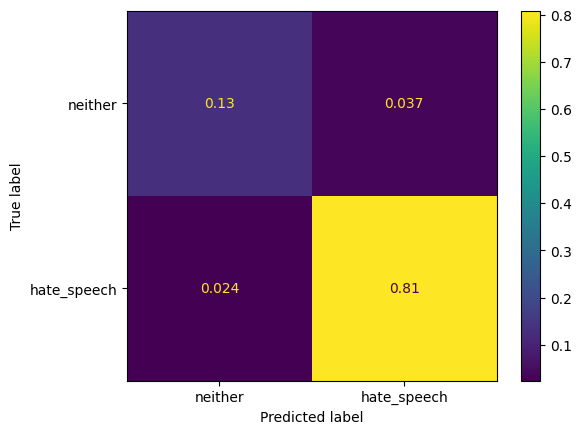

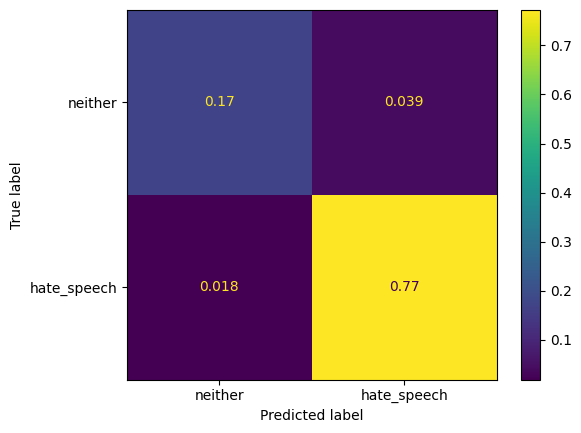

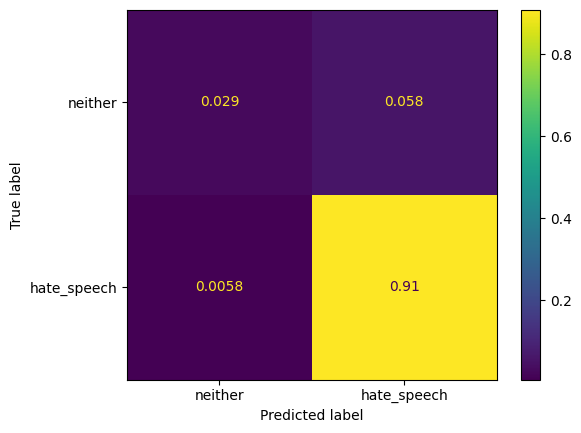

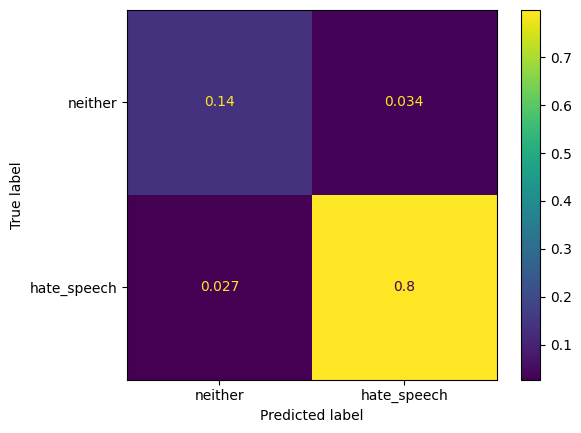

In [45]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, r2_score, mean_absolute_error, f1_score , confusion_matrix, ConfusionMatrixDisplay



print("-----------------")
print("Overall Metrics")
print("-----------------")
f1_score_All = f1_score(labels_All, pred_All, average='binary')
print(f"F1 Score: {f1_score_All:.3f}")
cm = confusion_matrix(labels_All, pred_All, normalize='all')
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.config.id2label.values()).plot()

print("-----------------")
print("Male Metrics")
print("-----------------")
f1_score_male = f1_score(labels_male, pred_male, average='binary')
print(f"F1 Score: {f1_score_male:.3f}")
cm = confusion_matrix(labels_male, pred_male, normalize='all')
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.config.id2label.values()).plot()

print("-----------------")
print("Female Metrics")
print("-----------------")
f1_score_female = f1_score(labels_female, pred_female, average='binary')
print(f"F1 Score: {f1_score_female:.3f}")
cm = confusion_matrix(labels_female, pred_female, normalize='all')
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.config.id2label.values()).plot()

print("-----------------")
print("Neutral Metrics")
print("-----------------")
f1_score_neutral = f1_score(labels_neutral, pred_neutral, average='binary')
print(f"F1 Score: {f1_score_neutral:.3f}")
cm = confusion_matrix(labels_neutral, pred_neutral, normalize='all')
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.config.id2label.values()).plot()


In [46]:
#true positiv gap

#true positiv gap
from sklearn.metrics import recall_score


hate_recall = recall_score(labels_All, pred_All, pos_label=1)
neither_recall = recall_score(labels_All, pred_All, pos_label=0)

print(f"Hate Speech Recall: {hate_recall:.3f}")
print(f"Neither Recall: {neither_recall:.3f}")

male_hate_recall = recall_score(labels_male, pred_male, pos_label=1)
male_neither_recall = recall_score(labels_male, pred_male, pos_label=0)

print(f"Male Hate Speech Recall: {male_hate_recall:.3f}")
print(f"Male Neither Recall: {male_neither_recall:.3f}")

female_hate_recall = recall_score(labels_female, pred_female, pos_label=1)
female_neither_recall = recall_score(labels_female, pred_female, pos_label=0)

print(f"Female Hate Speech Recall: {female_hate_recall:.3f}")
print(f"Female Neither Recall: {female_neither_recall:.3f}")

hate_gap = female_hate_recall - male_hate_recall
neither_gap = female_neither_recall - male_neither_recall

print(f"Hate Speech Recall Gap (Female - Male): {hate_gap:.3f}")
print(f"Neither Recall Gap (Female - Male): {neither_gap:.3f}")

Hate Speech Recall: 0.971
Neither Recall: 0.782
Male Hate Speech Recall: 0.977
Male Neither Recall: 0.813
Female Hate Speech Recall: 0.994
Female Neither Recall: 0.333
Hate Speech Recall Gap (Female - Male): 0.017
Neither Recall Gap (Female - Male): -0.480
